# 1. Introduction: The Bjerknes Mechanism & ENSO

## The Context

The *El Niño-Southern Oscillation (ENSO)* is the most significant driver of year-to-year climate variability on Earth. It manifests as a periodic fluctuation in sea surface temperatures (SSTs) and air pressure across the equatorial Pacific, with far-reaching consequences for global weather patterns, agriculture, and ecosystems. Understanding the mechanisms that trigger these shifts is a cornerstone of modern climate science.

## The Foundation: Bjerknes (1969)

In his seminal 1969 paper, Atmospheric Teleconnections from the Equatorial Pacific, Jacob Bjerknes proposed a breakthrough explanation for how the ocean and atmosphere "talk" to each other to maintain or break these climate states. He identified a positive feedback loop:
1. Cooling: Anomalous cooling in the eastern Pacific creates a larger temperature contrast across the basin.
2. Circulation: This increases the pressure gradient, which accelerates the trade winds.
3. Upwelling: Stronger trade winds enhance the upwelling of cold, deep water in the east, which further cools the surface, reinforcing the cycle.

This feedback loop is now known as the Bjerknes Mechanism. When this loop is strong, the Walker Circulation (the tropical atmospheric overturning cell) is vigorous; when it breaks down, we experience the warming events known as El Niño.Notebook GoalTo understand this mechanism, we must look beyond just temperature and examine the atmospheric pressure field. In this notebook, we recreate Bjerknes’s diagnostic method to visualize how basin-wide atmospheric pressure shifts ($\Delta\bar{p}$) influence the alignment of pressure gradients and isallobaric changes. By doing so, we will demonstrate the specific dynamical "triggers" that allow the atmosphere to shift between cold (La Niña) and warm (El Niño) regimes.

Notebook Goal: To understand this mechanism, we must look beyond just temperature and examine the atmospheric pressure field. In this notebook, we recreate Bjerknes’s diagnostic method to visualize how basin-wide atmospheric pressure shifts ($\Delta\bar{p}$) influence the alignment of pressure gradients and isallobaric changes. By doing so, we will demonstrate the specific dynamical "triggers" that allow the atmosphere to shift between cold (La Niña) and warm (El Niño) regimes.

Prerequisites: Ensure you have numpy and matplotlib installed. This notebook assumes familiarity with basic calculus and the behavior of the *tanh* function.

# 2. Mathematical Framework: Modeling the Pressure Field

To study the Walker Circulation, we model the sea-level pressure across the Pacific using a hyperbolic tangent function. This allows us to represent a smooth pressure transition from the high-pressure eastern Pacific to the low-pressure western Pacific:
$$p(x) = \bar{p} - A \cdot \tanh\left(\frac{x - x_0}{w}\right)$$

## Key Parameters:
+ $A$: The amplitude (strength) of the pressure anomaly.
+ $x_0$: The longitudinal center (the "midpoint") of the system.
+ $w$: The width (spatial extent) of the gradient.

## Why tanh?
The tanh function is ideal because it creates a single, monotonic slope. Because our basin-wide offset mechanism ($\Delta\bar{p}$) acts as a uniform shift, it effectively translates this curve up or down. Mathematically, this means that for any given scenario, there is at most one primary intersection point (node). This simplifies our diagnostic to a "single-knob" system, making it an excellent tool for demonstrating the core physics of ENSO.

# 3. Experimental Setup: The "Knob" Physics

In our model, dpbar ($\Delta\bar{p}$) acts as our primary control parameter. Mathematically, it applies a vertical shift between our $t$ and $t+\Delta t$ pressure states. Physically, this represents a basin-wide atmospheric forcing—a change that affects the entire Pacific region simultaneously, independent of the localized Walker Circulation.

## How the "Knob" Controls the Feedback:
The Bjerknes mechanism relies on a "node" (a zero-crossing) where the atmosphere is dynamically sensitive to changes. Our dpbar knob moves this node along the Pacific basin:
+ If $|\Delta\bar{p}| < |A_2 - A_1|$: The system maintains a localized crossing point. The feedback loop remains "locked" to a specific longitude.
+ If $|\Delta\bar{p}| \geq |A_2 - A_1|$: The system experiences a basin-wide shift so strong that the local "node" disappears, effectively breaking the localized feedback.

## Experimental Design Guide:
When you run the diagnostic, you are testing the atmosphere's resilience to these pressure anomalies. Refer to the table below as you experiment with different values:

| Scenario | Value (`dpbar`) | Climate Interpretation |
| :--- | :--- | :--- |
| **A** | `0.0` | **Cold Year:** Perfect feedback alignment. |
| **B** | `1.6` | **El Niño:** Basin-wide rise, feedback breakdown. |
| **C** | `0.35` | **Neutral-East:** Node migrates Eastward. |
| **D** | `-0.35` | **Neutral-West:** Node migrates Westward. |

# 4. The Diagnostic Engine: Tracking Atmospheric Change

To understand how the Walker Circulation responds to climate forcing, we need to move beyond just looking at plots. We need to identify specific, physical "nodes" that tell us where the atmosphere is active and where it is static. Following Bjerknes’s diagnostic approach, we focus on two primary markers:

## ① The Zero Isallobar: The "Node" of Change

The isallobar represents the pressure tendency—the difference in pressure between two times, $t$ and $t + \Delta t$:
$$\Delta p(x) = p(x, t + \Delta t) - p(x, t)$$
The Zero Isallobar is the specific location where $\Delta p = 0$. Physically, this is the "pivot point" of the atmosphere. If $\Delta p$ is positive on one side and negative on the other, the zero-crossing acts as a dynamic node around which the atmosphere reconfigures itself.

## ② The Gradient Maximum: The "Core" of Circulation

The spatial pressure gradient is the rate of change of pressure with respect to longitude:
$$\text{Gradient} = \frac{\partial p}{\partial x}$$
The Gradient Maximum is the point where the slope of the pressure field is steepest. In the tropical Pacific, this steepest point marks the "center of gravity" of the Walker Circulation—it is where the trade winds are strongest and the atmospheric overturning is most vigorous.

## A Note on Numerical Diagnostics

In this notebook, we calculate these markers numerically.

Zero-crossing: We use numerical root-finding to locate exactly where $\Delta p$ crosses the zero threshold. This allows us to track the atmosphere's "dynamic node" as it shifts east or west in response to climate anomalies.Gradient Maximum: By calculating the gradient of the pressure field, we identify the peak intensity of the circulation.

## Why does this matter? 

When these two points (the Node and the Gradient Max) are co-located, the atmosphere is in a state of high-efficiency feedback (the Bjerknes Mechanism). When they decouple or disappear, the system is signaling a transition toward an El Niño or La Niña state.

In the next cell, we will define the functions find_zero_crossings and np.gradient. These are the "eyes" of our diagnostic engine—they allow us to mathematically pin-point these markers in any climate scenario we simulate.

# 5. Coding the Engine: Why np.gradient?

In our diagnostic engine, we need to know the steepness of our pressure field at every single longitude point. While a simple slope formula—$\frac{\Delta y}{\Delta x}$—can tell us the average change between two points, it isn't enough to identify the precise peak of the Walker Circulation. 

For that, we use the NumPy function np.gradient().

## Why np.gradient?
+ Continuous Analysis: Unlike a basic slope calculation, np.gradient computes the rate of change at every point across the entire array. This creates a smooth, continuous curve that allows us to see exactly where the pressure gradient is at its absolute steepest.
+ Sensitivity: By using this, we can accurately track the "center of gravity" of the atmosphere (the gradient maximum) even if the pressure field shifts, flattens, or distorts across different climate scenarios.

## The Coding Logic

In your code, you will see a line like this: g = np.gradient(p2, X). 
This tells Python to calculate the derivative of the pressure ($p2$) with respect to the longitude ($X$). Once we have this array of gradient values, we use np.argmin(g) to find the index of the most negative value—this index points us directly to the "valley" where the circulation is most intense.

*Mathematical Note*: Because our pressure curves are derived from a tanh function (which slopes downward), the steepest point will be a negative number. This is why we use argmin—it seeks out the "deepest" point in the gradient valley to find the core of the circulation.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
# Ensure your bjerknes_physics.py is in the same folder as this notebook
from bjerknes_physics import pressure, gradient, find_zero_crossings, get_regime

# Setup your axis (the longitudes)
X = np.linspace(120, 270, 1200)

In [15]:
# Colour constants
C_PT   = "#1f77b4"    # p(t) blue
C_PTD  = "#e8593c"    # p(t+Δt) red-orange
C_DP   = "teal"       # Δp green
C_GRAD = "purple"     # gradient purple

from matplotlib.lines import Line2D

LON_TICKS  = [120, 150, 180, 210, 240, 270]
LON_LABELS = ["120°E", "150°E", "180°", "150°W", "120°W", "90°W"]

def plot_bjerknes_diagnostic(dpbar, scenario_title="", subtitle="",
                             A1=3.5, A2=4.2, x0=185.0, w=22.0, base=1010.0):
    p1 = pressure(X, A1, x0, w, base)
    p2 = pressure(X, A2, x0, w, base + dpbar)
    dp = p2 - p1
    g = np.gradient(p2, X)
    crossings = find_zero_crossings(X, dp)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    ax1, ax2, ax3, ax4 = axes.ravel()

    # title + subtitle
    fig.suptitle(scenario_title, fontsize=15, fontweight="bold", y=0.99)
    fig.text(0.5, 0.955, subtitle, fontsize=9, ha="center", va="top",
             color="grey", style="italic", wrap=True)

    # overall legend
    legend_handles = [
        Line2D([0], [0], color=C_PT,   lw=2, ls="-",  label=r"$p(t)$ — pressure at time $t$"),
        Line2D([0], [0], color=C_PTD,  lw=2, ls="--", label=r"$p(t{+}\Delta t)$ — pressure after interval"),
        Line2D([0], [0], color=C_DP,   lw=2, ls="-",  label=r"$\Delta p$ — isallobaric change"),
        Line2D([0], [0], color=C_GRAD, lw=2, ls="-",  label=r"$\partial p / \partial x$ — spatial gradient"),
        Line2D([0], [0], color="grey",  lw=1, ls="--", label="zero line"),
    ]
    fig.legend(handles=legend_handles, loc="upper center",
               bbox_to_anchor=(0.5, 0.935), ncol=3, fontsize=8,
               frameon=True, edgecolor="#cccccc")

    # ① Raw pressure field
    ax1.set_title(r"① Raw pressure field — $p(x,\, t)$ and $p(x,\, t{+}\Delta t)$",
                  fontsize=10, loc="left", pad=10)
    ax1.plot(X, p1, color=C_PT, lw=2)
    ax1.plot(X, p2, color=C_PTD, lw=2, ls="--")
    ax1.set_ylabel("hPa")

    # ② Isallobaric change
    ax2.set_title(r"② Isallobaric change — $\Delta p(x) = p(t{+}\Delta t) - p(t)$",
                  fontsize=10, loc="left", pad=10)
    ax2.axhline(0, color="grey", lw=1, ls="--")
    ax2.plot(X, dp, color=C_DP, lw=2)
    ax2.fill_between(X, dp, 0, where=dp >= 0, color=C_DP, alpha=0.12)
    ax2.fill_between(X, dp, 0, where=dp < 0,  color=C_PTD, alpha=0.08)
    ax2.set_ylabel("hPa change")

    # ③ Zero isallobar crossing
    ax3.set_title(r"③ Zero isallobar crossing — where $\Delta p = 0$",
                  fontsize=10, loc="left", pad=10)
    ax3.axhline(0, color="grey", lw=1, ls="--")
    ax3.plot(X, dp, color=C_DP, lw=2)
    for c in crossings:
        ax3.plot(c, 0, "o", color="orange", ms=12, markeredgecolor="white", markeredgewidth=1.5)
    ax3.set_ylabel(r"$\Delta p$ (hPa)")

    # ④ Spatial gradient
    # Calculate gradient numerically from the actual p2 pressure field
    g = np.gradient(p2, X)
    
    # Find the index of the minimum (the steepest downward slope/valley)
    gmax_idx = np.argmin(g)
    g_peak_x = X[gmax_idx]
    g_peak_val = g[gmax_idx]

    ax4.set_title(r"④ Spatial gradient — $\partial p / \partial x$ and its maximum",
                  fontsize=10, loc="left", pad=10)
    ax4.axhline(0, color="grey", lw=1, ls="--")
    ax4.plot(X, g, color=C_GRAD, lw=2)
    
    # Plot the violet dot at the dynamic location
    ax4.plot(g_peak_x, g_peak_val, "o", color="violet", ms=14,
             markeredgecolor="white", markeredgewidth=1.5)
    ax4.set_ylabel("hPa/°lon")
    
    # common formatting
    for a in (ax1, ax2, ax3, ax4):
        a.set_xticks(LON_TICKS)
        a.set_xticklabels(LON_LABELS, fontsize=8)
        a.set_xlim(120, 270)
        a.grid(alpha=0.15)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()
    return crossings, x0

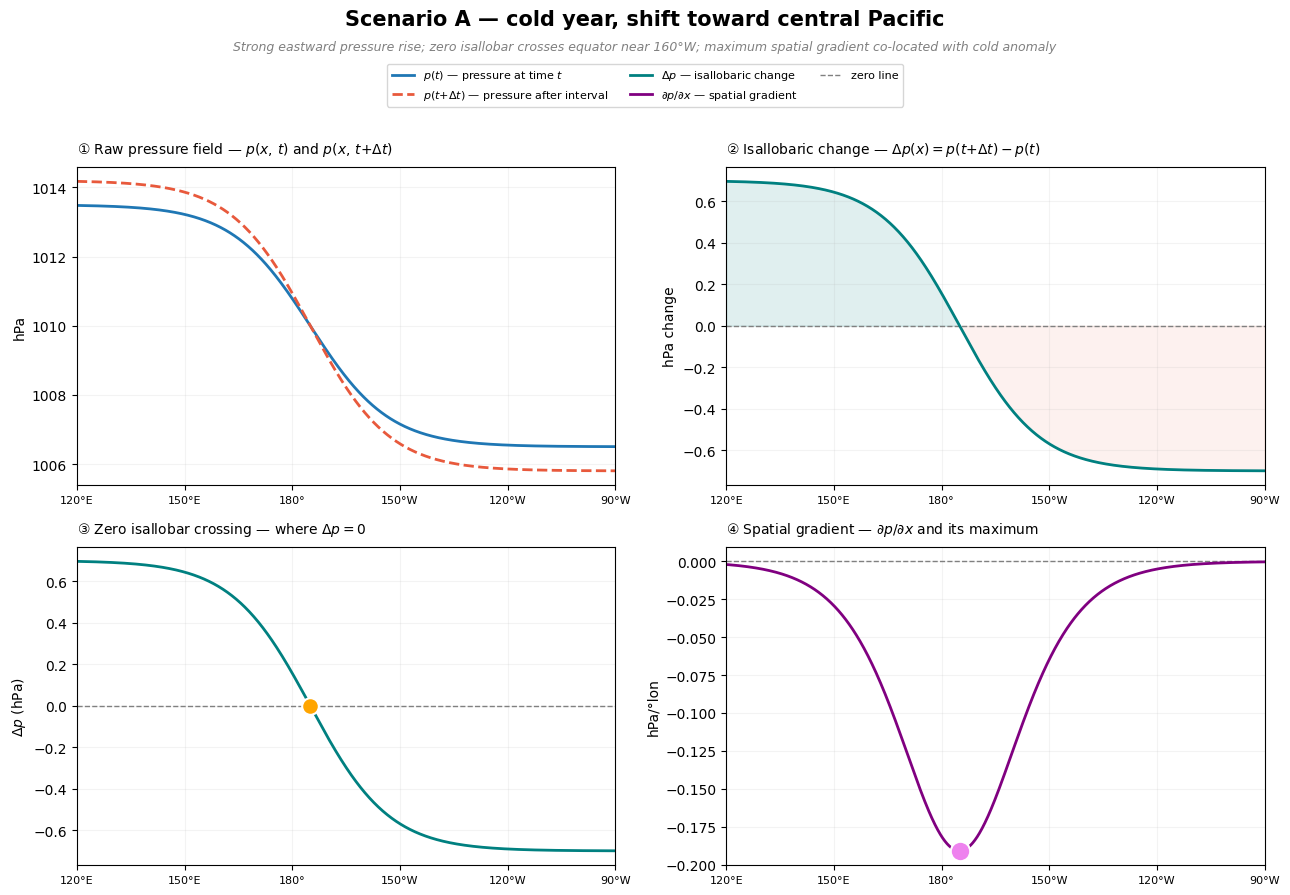

In [16]:
# Scenario A: The classic cold-year diagnostic
crossings_A, gmax = plot_bjerknes_diagnostic(
    dpbar=0.0,
    scenario_title="Scenario A — cold year, shift toward central Pacific",
    subtitle="Strong eastward pressure rise; zero isallobar crosses equator near 160°W; "
             "maximum spatial gradient co-located with cold anomaly"
)

In [17]:
# Sanity checks for all four scenarios
for name, dpbar in [("A cold", 0.0), ("B warm", 1.6), ("C neutral-east", 0.35), ("D neutral-west", -0.35)]:
    p1 = pressure(X, 3.5, 185.0, 22.0, 1010.0)
    p2 = pressure(X, 4.2, 185.0, 22.0, 1010.0 + dpbar)
    dp = p2 - p1
    cs = find_zero_crossings(X, dp)
    gmax = 185.0
    if cs:
        for c in cs:
            rel = "ON" if abs(c - gmax) < 0.5 else ("EAST of" if c > gmax else "WEST of")
            print(f"{name}:  crossing at {c:.1f}  |  gradient max at {gmax:.1f}  |  crossing is {rel} the max")
    else:
        print(f"{name}:  NO crossing  |  gradient max at {gmax:.1f}")

A cold:  crossing at 185.0  |  gradient max at 185.0  |  crossing is ON the max
B warm:  NO crossing  |  gradient max at 185.0
C neutral-east:  crossing at 197.1  |  gradient max at 185.0  |  crossing is EAST of the max
D neutral-west:  crossing at 172.9  |  gradient max at 185.0  |  crossing is WEST of the max


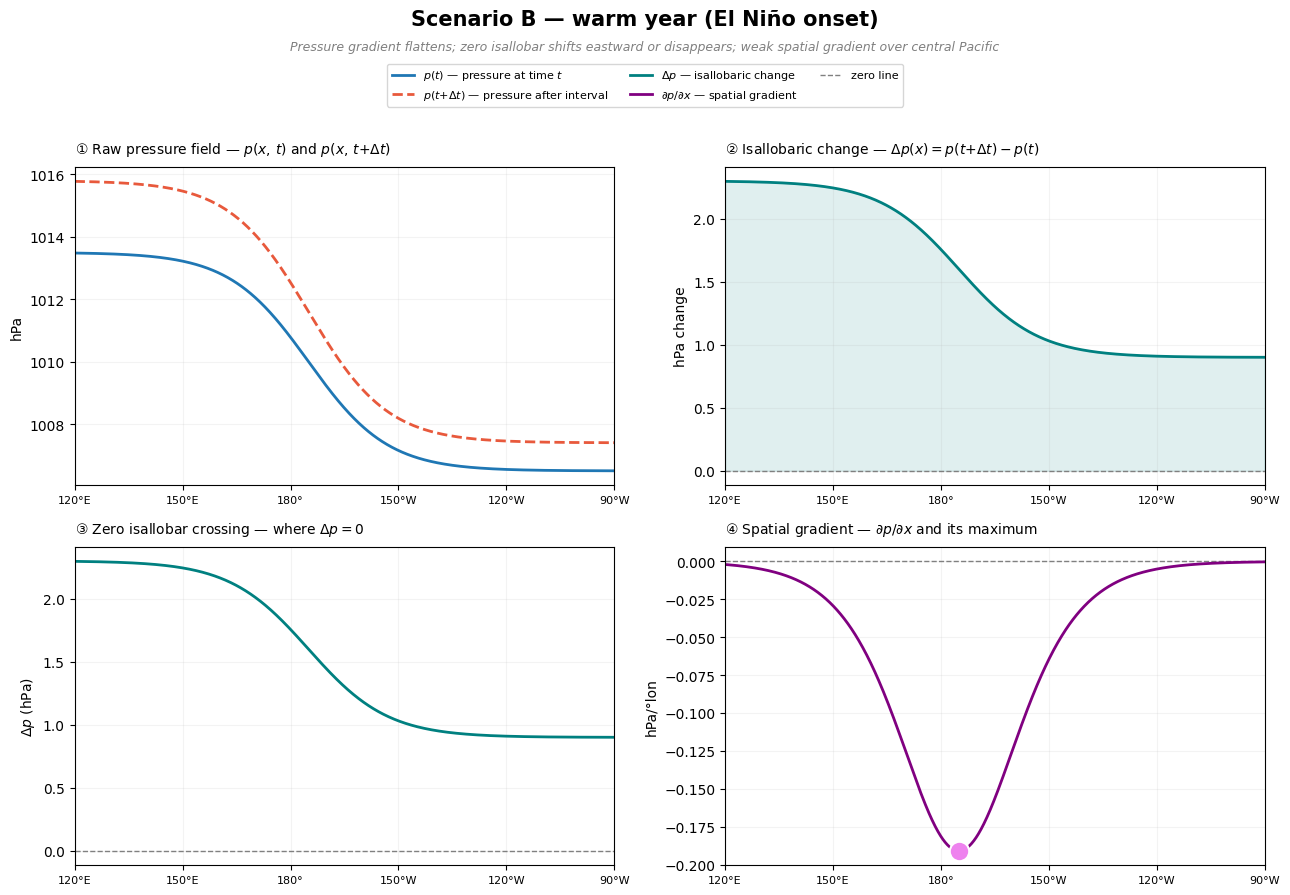

In [18]:
# Scenario B: warm year (El Niño onset)
crossings_B, gmax = plot_bjerknes_diagnostic(
    dpbar=1.6,
    scenario_title="Scenario B — warm year (El Niño onset)",
    subtitle="Pressure gradient flattens; zero isallobar shifts eastward or disappears; "
             "weak spatial gradient over central Pacific"
)

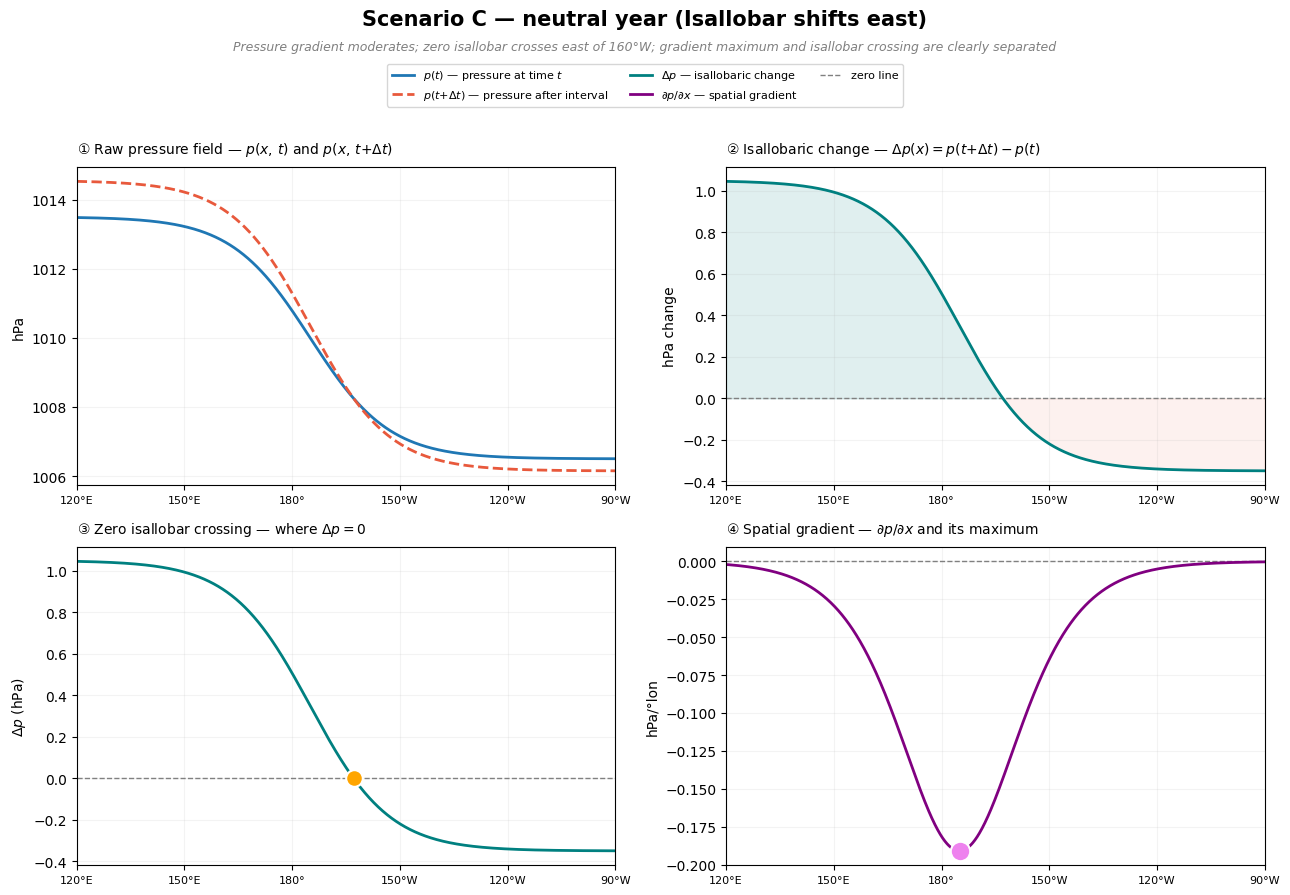

In [20]:
# Scenario C: neutral year (Isallobar shifts east)
crossings_C, gmax = plot_bjerknes_diagnostic(
    dpbar=0.35,
    scenario_title="Scenario C — neutral year (Isallobar shifts east)",
    subtitle="Pressure gradient moderates; zero isallobar crosses east of 160°W; "
             "gradient maximum and isallobar crossing are clearly separated"
)

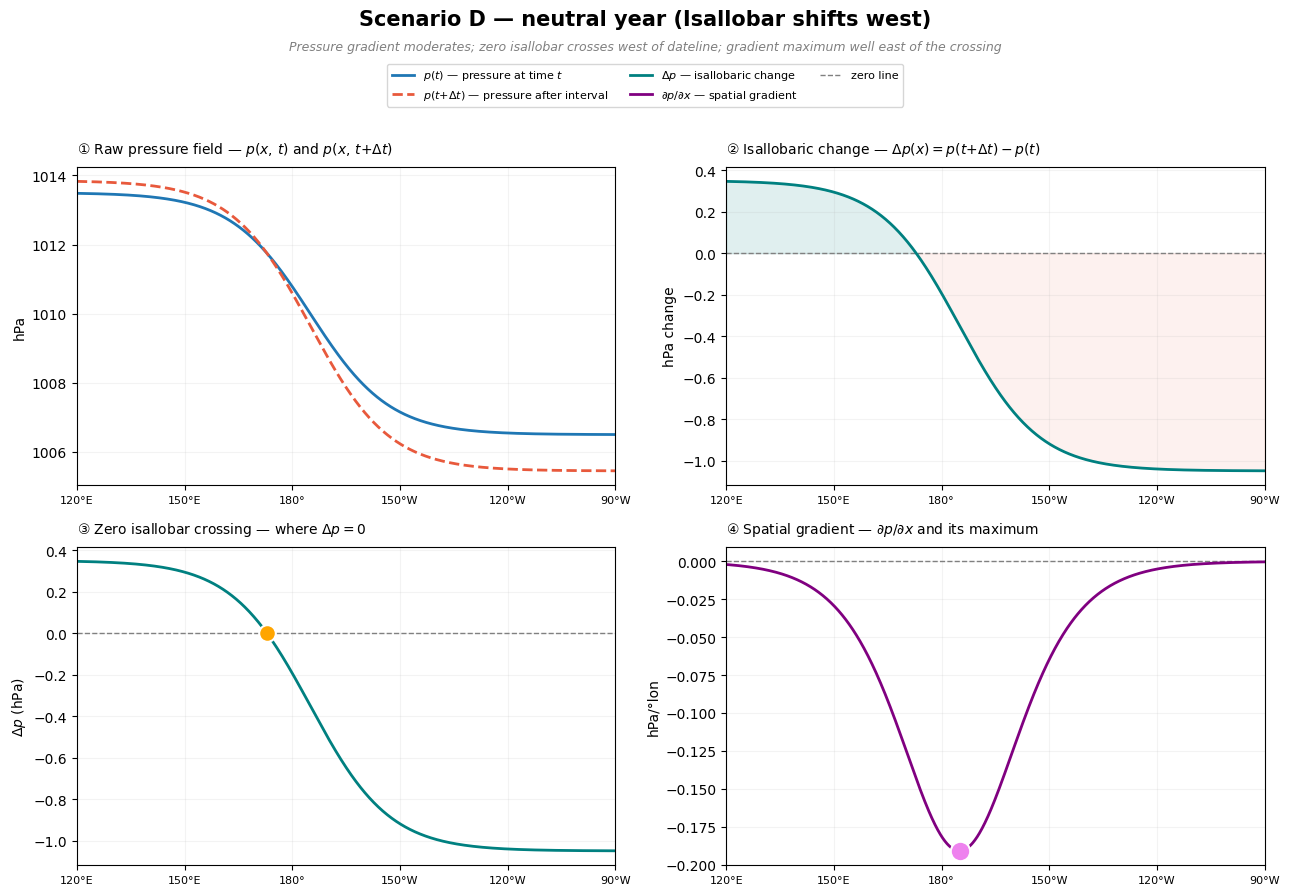

In [21]:
# Scenario D: neutral year (Isallobar shifts west)
crossings_C, gmax = plot_bjerknes_diagnostic(
    dpbar= -0.35,
    scenario_title="Scenario D — neutral year (Isallobar shifts west)",
    subtitle="Pressure gradient moderates; zero isallobar crosses west of dateline; "
             "gradient maximum well east of the crossing"
)

In [3]:
cd /home/claude && cat > build_nb.py << 'PYEOF'
import json

cells = []
def md(text): cells.append({"cell_type":"markdown","metadata":{},"source":text})
def code(text): cells.append({"cell_type":"code","metadata":{},"execution_count":None,"outputs":[],"source":text})

md(r"""# The zero isallobar vs the pressure-gradient maximum
### Idealised equatorial ENSO calculations — Bjerknes (1969), worked through

This notebook builds the four-step calculation behind Bjerknes (1969) from scratch, on idealised pressure fields, and shows **all the qualitatively distinct scenarios** rather than only the cold-year case the paper illustrates.

The single idea the notebook is built to make obvious:

> **"Where did pressure stop changing?"** (the zero isallobar, a statement about *time*: ∂p/∂t = 0)
> is a different question from
> **"Where is the pressure field steepest right now?"** (the gradient maximum, a statement about *space*: |∂p/∂x| peaks).

In certain cold years the two answers nearly coincide. In most years they don't. The notebook derives *why*, and shows there are exactly four qualitative outcomes — generated by a single physical knob.""")

md(r"""## 1. The set-up

Along the Equator we model sea-level pressure as a smooth west-to-east profile — high pressure in the west, low in the east. That is the Walker pattern. A `tanh` captures it with four interpretable parameters:

$$p(x) = p_{\text{base}} \; - \; A\,\tanh\!\left(\frac{x - x_0}{w}\right)$$

| parameter | meaning | controls |
|---|---|---|
| $A$ | amplitude (half the east-west pressure difference) | **strength** of the Walker gradient |
| $x_0$ | inflection longitude | **location of the steepest slope** = the gradient maximum |
| $w$ | width | how sharp vs spread-out the slope is |
| $p_{\text{base}}$ | mean level | a **basin-wide** offset (uniform up/down) |

Two key facts that fall straight out of this form:

- The **spatial gradient** $\partial p/\partial x = -\dfrac{A}{w}\,\operatorname{sech}^2\!\left(\dfrac{x-x_0}{w}\right)$ is most negative exactly at $x = x_0$. **The gradient maximum sits at $x_0$.**
- The **isallobaric change** $\Delta p(x) = p(x,\,t{+}\Delta t) - p(x,\,t)$ is the difference of two such profiles. Its **zero crossings** are the longitudes where the zero isallobar meets the Equator.""")

code(r"""%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt""")

code(r'''def pressure(x, A, x0, w, base):
    """Idealised equatorial SLP: high in the west, low in the east (Walker pattern)."""
    return base - A * np.tanh((x - x0) / w)

def gradient(x, A, x0, w):
    """Spatial gradient dp/dx (analytic). Most negative at x = x0 -> that is the gradient maximum."""
    return -(A / w) * (1.0 / np.cosh((x - x0) / w))**2''')

code(r'''# Longitude axis: 120E -> 90W as a continuous coordinate (180 = dateline).
# 120..180 are E longitudes; 180..270 map to 180W..90W.
X = np.linspace(120, 270, 1200)

def lon_label(v):
    if abs(v - 180) < 1e-9: return "180\u00b0"
    return f"{v:.0f}\u00b0E" if v < 180 else f"{360 - v:.0f}\u00b0W"

def find_zero_crossings(xv, yv):
    """Return the longitudes where yv changes sign (linear interpolation to the zero)."""
    s = np.sign(yv)
    out = []
    for i in np.where(np.diff(s) != 0)[0]:
        out.append(xv[i] - yv[i] * (xv[i+1] - xv[i]) / (yv[i+1] - yv[i]))
    return out''')

code(r'''def four_steps(dpbar, A1=3.5, A2=4.2, x0=185.0, w=22.0, base=1010.0, title=""):
    """Run and plot the full 4-step diagnostic for one scenario.

    dpbar : the BASIN-WIDE uniform pressure offset applied between t and t+dt.
            This single number is the knob that moves the crossing.
    A1, A2: Walker amplitude before / after  (A2 > A1 == intensification).
    x0    : gradient-maximum longitude (held fixed across the set).
    """
    p1 = pressure(X, A1, x0, w, base)
    p2 = pressure(X, A2, x0, w, base + dpbar)   # intensify AND shift the whole basin by dpbar
    dp = p2 - p1
    g  = gradient(X, A2, x0, w)
    crossings = find_zero_crossings(X, dp)
    gmax = x0                                    # analytic gradient-max longitude

    ticks = [120, 150, 180, 210, 240, 270]
    tlabs = [lon_label(t) for t in ticks]
    fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
    if title:
        fig.suptitle(title, fontsize=13, weight="bold")

    a = ax[0, 0]
    a.plot(X, p1, label="p(t)")
    a.plot(X, p2, "--", label="p(t+\u0394t)")
    a.set_title("\u2460 Raw pressure field"); a.set_ylabel("hPa"); a.legend(loc="upper right")

    a = ax[0, 1]
    a.axhline(0, ls="--", color="grey", lw=1)
    a.plot(X, dp, color="teal")
    a.fill_between(X, dp, 0, where=dp > 0, color="teal", alpha=0.15)
    a.fill_between(X, dp, 0, where=dp < 0, color="brown", alpha=0.15)
    a.set_title("\u2461 Isallobaric change  \u0394p = p(t+\u0394t) \u2212 p(t)"); a.set_ylabel("hPa change")

    a = ax[1, 0]
    a.axhline(0, ls="--", color="grey", lw=1)
    a.plot(X, dp, color="teal")
    for c in crossings:
        a.plot(c, 0, "o", color="orange", ms=10, zorder=5)
    a.set_title("\u2462 Zero isallobar \u2014 where \u0394p = 0"); a.set_ylabel("\u0394p (hPa)")

    a = ax[1, 1]
    a.axhline(0, ls="--", color="grey", lw=1)
    a.plot(X, g, color="purple")
    a.plot(gmax, gradient(np.array([gmax]), A2, x0, w)[0], "o", color="violet", ms=12, zorder=5)
    a.set_title("\u2463 Spatial gradient \u2202p/\u2202x and its maximum"); a.set_ylabel("hPa/\u00b0lon")

    for a in ax.ravel():
        a.set_xticks(ticks); a.set_xticklabels(tlabs); a.set_xlim(120, 270); a.grid(alpha=0.15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    if crossings:
        c = crossings[0]
        rel = "EAST of" if c > gmax + 0.5 else ("WEST of" if c < gmax - 0.5 else "ON")
        print(f"crossing at {lon_label(c)}   |   gradient max at {lon_label(gmax)}   "
              f"|   crossing is {rel} the gradient max")
    else:
        print(f"NO equatorial crossing   |   gradient max at {lon_label(gmax)}")
    return crossings, gmax''')

md(r"""## 2. The one knob that generates everything

We hold the geometry fixed — the Walker gradient **intensifies** ($A: 3.5 \to 4.2$) about a **fixed** centre $x_0$ (so the gradient maximum never moves) — and vary a single number:

$$\Delta\bar p \;=\; \text{basin-wide uniform pressure change between } t \text{ and } t{+}\Delta t.$$

Physically $\Delta\bar p$ is the *mass-exchange* term of the Southern Oscillation: pressure rising or falling across the **whole** Pacific relative to the rest of the globe, on top of the local steepening.

Working the algebra, the change field is

$$\Delta p(x) = \Delta\bar p \; - \; (A_2 - A_1)\,\tanh\!\left(\frac{x-x_0}{w}\right),$$

so the crossing sits where

$$\tanh\!\left(\frac{x-x_0}{w}\right) = \frac{\Delta\bar p}{A_2 - A_1}.$$

Everything follows from that ratio:

| $\Delta\bar p$ | ratio | crossing | regime |
|---|---|---|---|
| $0$ | $0$ | exactly at $x_0$ | **A** — coincides with gradient max |
| small $> 0$ | $0<\cdot<1$ | east of $x_0$ | **C** — crossing east of max |
| small $< 0$ | $-1<\cdot<0$ | west of $x_0$ | **D** — crossing west of max |
| $\lvert\Delta\bar p\rvert > A_2-A_1$ | $\lvert\cdot\rvert>1$ | none | **B** — no crossing |""")

md("""## 3. Scenario A \u2014 cold year (crossing coincides with the gradient maximum)

The Walker gradient intensifies with **no** basin-wide offset ($\\Delta\\bar p = 0$). The isallobaric change is a clean dipole centred on $x_0$, so its zero sits **exactly on** the gradient maximum. This is Bjerknes's cold-year diagnostic: the temporal node and the spatial peak answer to the same longitude.""")
code('crossings, gmax = four_steps(dpbar=0.0, title="Scenario A \u2014 cold year (crossing coincides with gradient max)")')

md("""## 4. Scenario B \u2014 warm year (no clear mid-Pacific crossing)

A large basin-wide pressure **rise** ($\\Delta\\bar p = 1.6$, bigger than the gradient change $A_2-A_1=0.7$) lifts the entire $\\Delta p$ curve above zero. The see-saw node is pushed off the Pacific altogether: **there is no equatorial crossing.** This is the El Ni\u00f1o-onset breakdown \u2014 the diagnostic the cold-year picture would never warn you about.""")
code('crossings, gmax = four_steps(dpbar=1.6, title="Scenario B \u2014 warm year (no mid-Pacific crossing)")')

md("""## 5. Scenario C \u2014 neutral (crossing east of the gradient maximum)

A modest basin-wide **rise** ($\\Delta\\bar p = +0.35$) slides the zero **east** of $x_0$. The gradient maximum has not moved \u2014 only the crossing has. Temporal node and spatial peak are now clearly different longitudes.""")
code('crossings, gmax = four_steps(dpbar=0.35, title="Scenario C \u2014 neutral, crossing east of gradient max")')

md("""## 6. Scenario D \u2014 neutral (crossing west of the gradient maximum)

A modest basin-wide **fall** ($\\Delta\\bar p = -0.35$) slides the zero **west** of $x_0$, to the far side of the dateline, while the gradient maximum stays put in the central Pacific. This is the mirror image of C \u2014 the crossing now sits west of the steepest slope.""")
code('crossings, gmax = four_steps(dpbar=-0.35, title="Scenario D \u2014 neutral, crossing west of gradient max")')

md(r"""## 7. Are there more scenarios?

At the level that matters for the diagnostic — **where the crossing sits relative to the gradient maximum** — there are exactly **four** outcomes, because two points on a line can only be arranged four ways: *the first east of the second, on it, west of it, or not present at all.* That is logically complete.

The sweep below makes it visual. As the single knob $\Delta\bar p$ runs from negative to positive, the crossing migrates continuously from west of the gradient max, through it (at $\Delta\bar p=0$), to east of it — and **disappears** entirely once $\lvert\Delta\bar p\rvert$ exceeds the gradient change. Four regions, no fifth.""")

code(r'''A1, A2, x0, w, base = 3.5, 4.2, 185.0, 22.0, 1010.0
dA = A2 - A1
dps = np.linspace(-1.2, 1.2, 600)
xc = []
for d in dps:
    dp = pressure(X, A2, x0, w, base + d) - pressure(X, A1, x0, w, base)
    cs = find_zero_crossings(X, dp)
    xc.append(cs[0] if cs else np.nan)
xc = np.array(xc)

plt.figure(figsize=(9.5, 4.8))
plt.axvspan(-1.2, -dA, color="grey",   alpha=0.18, label="B: no crossing")
plt.axvspan(-dA,   0.0, color="orange", alpha=0.12, label="D: crossing west of max")
plt.axvspan( 0.0,   dA, color="teal",   alpha=0.12, label="C: crossing east of max")
plt.axvspan( dA,  1.2, color="grey",   alpha=0.18)
plt.axhline(x0, color="violet", lw=2.5, label="gradient max (fixed, 175\u00b0W)")
plt.plot(dps, xc, color="darkorange", lw=2.5, label="zero-isallobar crossing")
plt.axvline(0, color="k", lw=0.8, ls=":")
plt.scatter([0], [x0], color="red", zorder=6, label="A: coincide (\u0394p\u0304=0)")
yt = [150, 165, 180, 195, 210, 225]
plt.yticks(yt, [lon_label(v) for v in yt])
plt.xlabel("\u0394p\u0304  (basin-wide pressure change, hPa)")
plt.ylabel("crossing longitude")
plt.title("One knob, four regimes: crossing position vs basin-wide offset")
plt.legend(fontsize=8, loc="upper left", ncol=2); plt.grid(alpha=0.15)
plt.tight_layout(); plt.show()
print(f"gradient change A2-A1 = {dA:.2f} hPa  -> crossing exists only while |\u0394p\u0304| < {dA:.2f}")''')

md(r"""## 8. The same four outcomes via a *different* driver

Four outcomes does not mean one mechanism. The basin-wide offset above is the cleanest knob, but a **horizontal shift** of the whole pattern (the inflection migrating between $t$ and $t{+}\Delta t$) reaches the same C/D separation by another route — here the gradient maximum *does* move, and the crossing lands between the old and new centres. The lesson stands: the crossing and the gradient maximum are independent objects, and several physical changes can prise them apart.""")

code(r'''def shifted_case(shift, A=3.8, w=22.0, base=1010.0, x0=185.0):
    """Whole pattern migrates by `shift` degrees (no amplitude or basin change)."""
    x0_1, x0_2 = x0, x0 + shift          # centre moves between the two times
    p1 = pressure(X, A, x0_1, w, base)
    p2 = pressure(X, A, x0_2, w, base)
    dp = p2 - p1
    cs = find_zero_crossings(X, dp)
    gmax = x0_2                            # gradient max of the LATER field
    c = cs[0] if cs else None
    tag = "no crossing" if c is None else (
        f"crossing {lon_label(c)}, gradient max {lon_label(gmax)} -> "
        + ("EAST" if c > gmax else "WEST") + " of max")
    return dp, gmax, cs, tag

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, shift, name in [(ax[0], +18, "pattern shifts EAST"), (ax[1], -18, "pattern shifts WEST")]:
    dp, gmax, cs, tag = shifted_case(shift)
    a.axhline(0, ls="--", color="grey", lw=1)
    a.plot(X, dp, color="teal")
    for c in cs: a.plot(c, 0, "o", color="orange", ms=9, zorder=5)
    a.axvline(gmax, color="violet", lw=2, alpha=0.7)
    a.set_title(f"{name}\n{tag}", fontsize=10)
    a.set_xticks([120,150,180,210,240,270]); a.set_xticklabels([lon_label(t) for t in [120,150,180,210,240,270]])
    a.set_xlim(120,270); a.grid(alpha=0.15); a.set_ylabel("\u0394p (hPa)")
plt.tight_layout(); plt.show()
print("Same east/west separation as C/D, produced by migration instead of a basin-wide offset.")''')

md("""## 9. A classifier you can point at any field

Given any pair of pressure profiles, this decides which regime you are in \u2014 the small automated version of the visual judgement above.""")

code(r'''def classify(p1, p2, x0, tol=0.5):
    dp = p2 - p1
    cs = find_zero_crossings(X, dp)
    if not cs:
        return "B  (no crossing)"
    c = cs[0]
    if abs(c - x0) <= tol:  return "A  (crossing coincides with gradient max)"
    return "C  (crossing east of max)" if c > x0 else "D  (crossing west of max)"

x0 = 185.0
print("Scenario sweep using the classifier:\n")
for dpbar, expect in [(0.0,"A"), (0.35,"C"), (-0.35,"D"), (1.6,"B")]:
    p1 = pressure(X, 3.5, x0, 22, 1010)
    p2 = pressure(X, 4.2, x0, 22, 1010 + dpbar)
    print(f"  \u0394p\u0304={dpbar:+.2f}  ->  {classify(p1, p2, x0)}")''')

md("""## 10. Optional: drag the knob yourself

If `ipywidgets` is installed (`pip install ipywidgets`), the slider below lets you move \u0394p\u0304 and watch the crossing migrate live. If it is not installed, skip this cell \u2014 everything above already runs without it.""")

code(r'''try:
    from ipywidgets import interact, FloatSlider
    interact(
        lambda dpbar: four_steps(dpbar, title=f"\u0394p\u0304 = {dpbar:+.2f}"),
        dpbar=FloatSlider(min=-1.5, max=1.5, step=0.05, value=0.0, description="\u0394p\u0304"),
    )
except Exception as e:
    print("ipywidgets not available \u2014 skip this cell. Reason:", e)''')

md(r"""## 11. Why this matters beyond the figure

The four panels exist to keep two questions apart: *where did pressure stop changing* (the zero isallobar, temporal) versus *where is the field steepest now* (the gradient maximum, spatial). The notebook shows they coincide only in the cold-year corner of parameter space ($\Delta\bar p \approx 0$) and separate — or vanish — everywhere else.

For catastrophe modelling the consequence is structural, not cosmetic. ENSO phase conditions tropical-cyclone genesis corridors, track densities, and basin-to-landfall return periods. A diagnostic that conflates the temporal node with the spatial peak will be:

- **precise** where it happens to be easy (cold years, where they coincide),
- **wrong by a fixed displacement** in the neutral years (C and D, in opposite directions),
- **confidently asserting a crossing that does not exist** in warm years (B).

That is a *regime-dependent* bias. It does not average out across a stochastic catalogue the way noise does — it shifts the ENSO-conditional frequency term in a patterned way, contaminates the loss curves fitted on phase-labelled samples, and ultimately geolocates hazard, exposure, and adaptation spend incorrectly. The whole point of working it through on idealised fields is to see the failure *before* it is buried under twelve layers of a real model.""")

nb = {
    "cells": cells,
    "metadata": {
        "kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"},
        "language_info": {"name": "python", "version": "3"},
    },
    "nbformat": 4,
    "nbformat_minor": 5,
}

with open("/home/claude/El_Nino_isallobar_scenarios.ipynb", "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)
print("notebook written:", len(cells), "cells")
PYEOF
python3 build_nb.py
Output
notebook written: 24 cells

SyntaxError: invalid syntax (3888230233.py, line 1)